In [21]:
# 1. IMPORTS & DATA LOADING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from xgboost import XGBClassifier, XGBRegressor
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Loading the dataset
df = pd.read_csv("mental_health_social_media_dataset.csv")
# Display basic info
print(df.head())
print("\nMental State Distribution:")
print(df['mental_state'].value_counts())

        person_name  age        date  gender   platform  \
0     Reyansh Ghosh   35  01-01-2024    Male  Instagram   
1        Neha Patel   24  01-12-2024  Female  Instagram   
2      Ananya Naidu   26  01-06-2024    Male   Snapchat   
3          Neha Das   66   1/17/2024  Female   Snapchat   
4  Reyansh Banerjee   31   1/28/2024    Male   Snapchat   

   daily_screen_time_min  social_media_time_min  negative_interactions_count  \
0                    320                    160                            1   
1                    453                    226                            1   
2                    357                    196                            1   
3                    190                    105                            0   
4                    383                    211                            1   

   positive_interactions_count  sleep_hours  physical_activity_min  \
0                            2          7.4                     28   
1                       

In [22]:
# 2. DATA PREPROCESSING (Common for all models)
# Target
label_col = 'mental_state'
le = LabelEncoder()
df['mental_state_encoded'] = le.fit_transform(df[label_col])
print("\nEncoded classes:", dict(zip(range(len(le.classes_)), le.classes_)))
# Drop irrelevant & direct indicator columns
df_processed = df.drop(['person_name', 'date', 'anxiety_level', 'stress_level', 'mood_level', label_col], axis=1)
# Features
cat_cols = ['gender', 'platform']
num_cols = ['age', 'daily_screen_time_min', 'social_media_time_min',
            'negative_interactions_count', 'positive_interactions_count',
            'sleep_hours', 'physical_activity_min']
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', QuantileTransformer(output_distribution='normal', random_state=42), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ])
# Split (stratified for classification)
X_train, X_test, y_train_class, y_test_class = train_test_split(
    df_processed, df['mental_state_encoded'], test_size=0.2, random_state=42, stratify=df['mental_state_encoded']
)
# For regression, use the same encoded numeric target (0=At_Risk, 1=Healthy, 2=Stressed)
y_train_reg = y_train_class
y_test_reg = y_test_class
# Transform features once (used across models)
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)


Encoded classes: {0: 'At_Risk', 1: 'Healthy', 2: 'Stressed'}



=== 1. Linear Regression (Treating mental_state as ordinal) ===
Accuracy: 0.9400
Precision (macro): 0.6463
Recall (macro): 0.4314
F1-score (macro): 0.4743
AUC (macro OvR): 0.9657


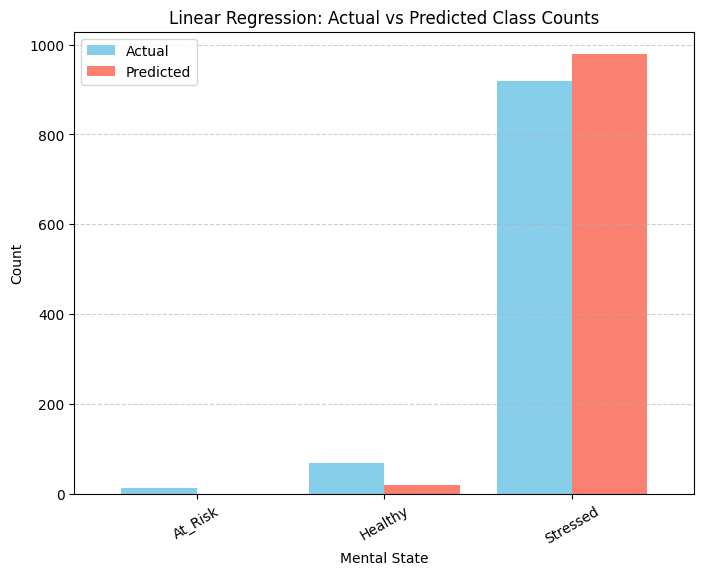

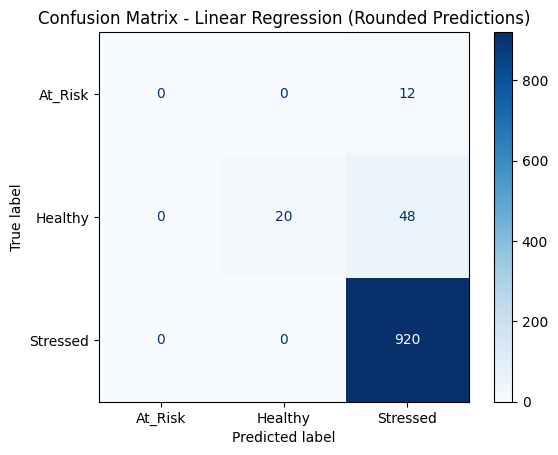

In [23]:
# 3.MODELS
# 1. LINEAR REGRESSION
print("\n=== 1. Linear Regression (Treating mental_state as ordinal) ===")
# Model
lin_reg = LinearRegression()
lin_reg.fit(X_train_preprocessed, y_train_reg)
# Predictions
y_pred_reg_lin = lin_reg.predict(X_test_preprocessed)
y_pred_class_lin = np.rint(y_pred_reg_lin).clip(0, 2).astype(int)  # Round to nearest class
# Classification Metrics (macro-averaged for multiclass & imbalance)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
acc_lin = accuracy_score(y_test_class, y_pred_class_lin)
prec_lin = precision_score(y_test_class, y_pred_class_lin, average='macro', zero_division=0)
rec_lin = recall_score(y_test_class, y_pred_class_lin, average='macro', zero_division=0)
f1_lin = f1_score(y_test_class, y_pred_class_lin, average='macro', zero_division=0)
# For AUC: use distance from class midpoint as pseudo-probability (common workaround for linear regression in ordinal tasks)
# Create pseudo-probabilities: distance to class centers [0, 1, 2]
pseudo_probs = np.zeros((len(y_pred_reg_lin), 3))
for i, pred in enumerate(y_pred_reg_lin):
    # Softmax-like probabilities based on distance to integer class centers
    distances = np.abs(pred - np.array([0, 1, 2]))
    inv_distances = 1 / (distances + 1e-8)
    pseudo_probs[i] = inv_distances / inv_distances.sum()
auc_lin = roc_auc_score(y_test_class, pseudo_probs, average='macro', multi_class='ovr')
print(f"Accuracy: {acc_lin:.4f}")
print(f"Precision (macro): {prec_lin:.4f}")
print(f"Recall (macro): {rec_lin:.4f}")
print(f"F1-score (macro): {f1_lin:.4f}")
print(f"AUC (macro OvR): {auc_lin:.4f}")
# Normal Bar Plot: Actual vs Predicted Class Counts
classes = le.classes_
actual_counts = pd.Series(le.inverse_transform(y_test_class)).value_counts().reindex(classes, fill_value=0)
pred_counts_lin = pd.Series(le.inverse_transform(y_pred_class_lin)).value_counts().reindex(classes, fill_value=0)
df_bar_lin = pd.DataFrame({'Actual': actual_counts, 'Predicted': pred_counts_lin})
df_bar_lin.plot(kind='bar', figsize=(8, 6), width=0.8, color=['skyblue', 'salmon'])
plt.title('Linear Regression: Actual vs Predicted Class Counts')
plt.ylabel('Count')
plt.xlabel('Mental State')
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
# Confusion Matrix (based on rounded predictions)
cm_lin = confusion_matrix(y_test_class, y_pred_class_lin)
disp_lin = ConfusionMatrixDisplay(confusion_matrix=cm_lin, display_labels=le.classes_)
disp_lin.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Linear Regression (Rounded Predictions)')
plt.show()


=== 2. Logistic Regression (Multiclass Classification) ===
Accuracy: 0.9850 | Precision: 0.8155 | Recall: 0.9855 | F1: 0.8674 | AUC: 0.9978


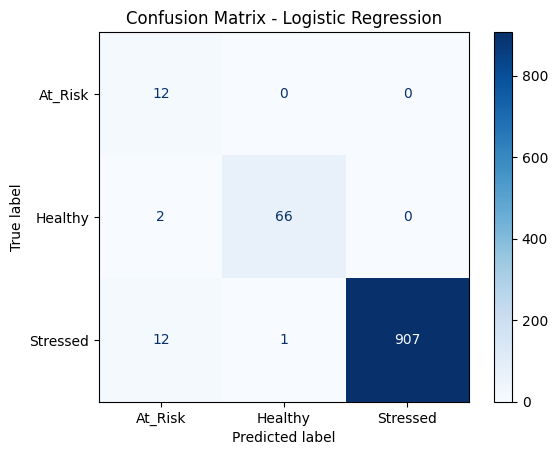

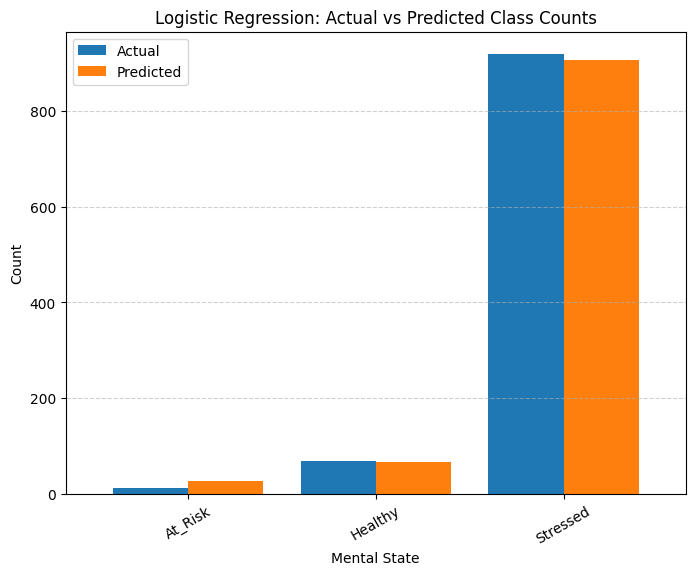

In [24]:
# 2. LOGISTIC REGRESSION SECTION
print("\n=== 2. Logistic Regression (Multiclass Classification) ===")
# Pipeline with SMOTE + balanced weights
log_pipe = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
log_pipe.fit(X_train_preprocessed, y_train_class)
# Predictions
y_pred_log = log_pipe.predict(X_test_preprocessed)
y_prob_log = log_pipe.predict_proba(X_test_preprocessed)
# Metrics (macro)
acc_log = accuracy_score(y_test_class, y_pred_log)
prec_log = precision_score(y_test_class, y_pred_log, average='macro')
rec_log = recall_score(y_test_class, y_pred_log, average='macro')
f1_log = f1_score(y_test_class, y_pred_log, average='macro')
auc_log = roc_auc_score(y_test_class, y_prob_log, average='macro', multi_class='ovr')
print(f"Accuracy: {acc_log:.4f} | Precision: {prec_log:.4f} | Recall: {rec_log:.4f} | F1: {f1_log:.4f} | AUC: {auc_log:.4f}")
# Confusion Matrix
cm_log = confusion_matrix(y_test_class, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=le.classes_)
disp_log.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()
# Actual vs Predicted Bar Plot
actual_counts_log = pd.Series(le.inverse_transform(y_test_class)).value_counts().reindex(classes, fill_value=0)
pred_counts_log = pd.Series(le.inverse_transform(y_pred_log)).value_counts().reindex(classes, fill_value=0)
df_bar_log = pd.DataFrame({'Actual': actual_counts_log, 'Predicted': pred_counts_log})
df_bar_log.plot(kind='bar', figsize=(8, 6), width=0.8)
plt.title('Logistic Regression: Actual vs Predicted Class Counts')
plt.ylabel('Count')
plt.xlabel('Mental State')
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


=== 3. Decision Tree Classifier ===
Accuracy: 0.9990 | Precision: 0.9996 | Recall: 0.9722 | F1: 0.9853 | AUC: 0.9840


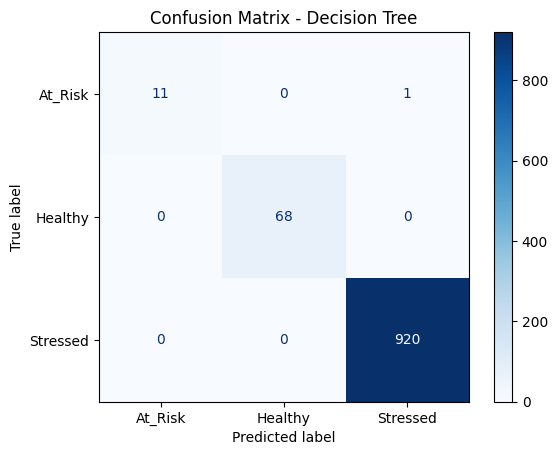

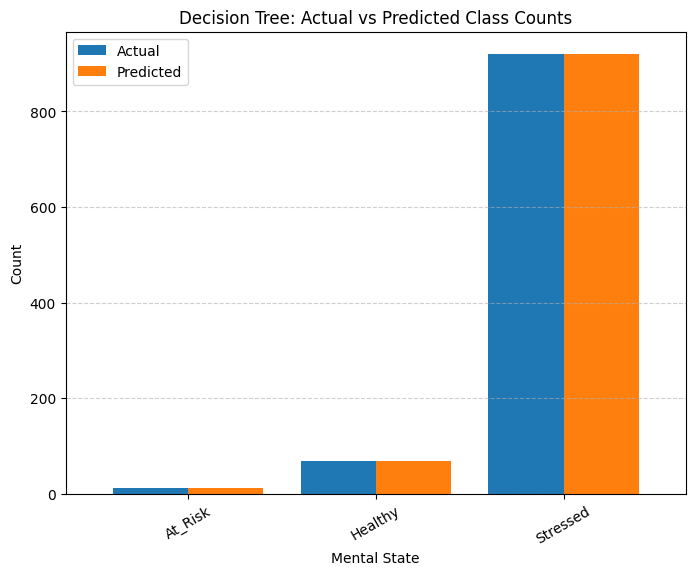

In [25]:
#3. DECISION TREE
print("\n=== 3. Decision Tree Classifier ===")
# Pipeline with SMOTE + balanced weights
dt_pipe = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])
dt_pipe.fit(X_train_preprocessed, y_train_class)
# Predictions
y_pred_dt = dt_pipe.predict(X_test_preprocessed)
y_prob_dt = dt_pipe.predict_proba(X_test_preprocessed)
# Metrics
acc_dt = accuracy_score(y_test_class, y_pred_dt)
prec_dt = precision_score(y_test_class, y_pred_dt, average='macro')
rec_dt = recall_score(y_test_class, y_pred_dt, average='macro')
f1_dt = f1_score(y_test_class, y_pred_dt, average='macro')
auc_dt = roc_auc_score(y_test_class, y_prob_dt, average='macro', multi_class='ovr')
print(f"Accuracy: {acc_dt:.4f} | Precision: {prec_dt:.4f} | Recall: {rec_dt:.4f} | F1: {f1_dt:.4f} | AUC: {auc_dt:.4f}")
# Confusion Matrix
cm_dt = confusion_matrix(y_test_class, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le.classes_)
disp_dt.plot(cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()
# Actual vs Predicted
pred_counts_dt = pd.Series(le.inverse_transform(y_pred_dt)).value_counts().reindex(classes, fill_value=0)
df_bar_dt = pd.DataFrame({'Actual': actual_counts_log, 'Predicted': pred_counts_dt})  # actual same for all
df_bar_dt.plot(kind='bar', figsize=(8, 6), width=0.8)
plt.title('Decision Tree: Actual vs Predicted Class Counts')
plt.ylabel('Count')
plt.xlabel('Mental State')
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


=== 4. Random Forest Classifier ===
Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000 | AUC: 1.0000


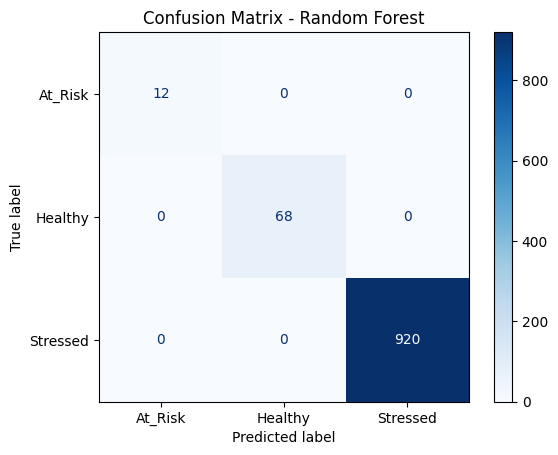

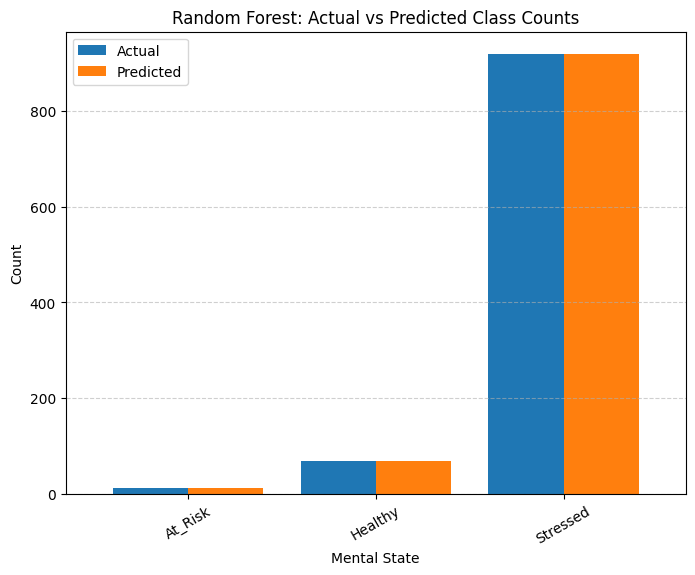

In [26]:
#4. RANDOM FOREST
print("\n=== 4. Random Forest Classifier ===")
# Pipeline with SMOTE + balanced weights
rf_pipe = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42))
])
rf_pipe.fit(X_train_preprocessed, y_train_class)
# Predictions
y_pred_rf = rf_pipe.predict(X_test_preprocessed)
y_prob_rf = rf_pipe.predict_proba(X_test_preprocessed)
# Metrics
acc_rf = accuracy_score(y_test_class, y_pred_rf)
prec_rf = precision_score(y_test_class, y_pred_rf, average='macro')
rec_rf = recall_score(y_test_class, y_pred_rf, average='macro')
f1_rf = f1_score(y_test_class, y_pred_rf, average='macro')
auc_rf = roc_auc_score(y_test_class, y_prob_rf, average='macro', multi_class='ovr')
print(f"Accuracy: {acc_rf:.4f} | Precision: {prec_rf:.4f} | Recall: {rec_rf:.4f} | F1: {f1_rf:.4f} | AUC: {auc_rf:.4f}")
# Confusion Matrix
cm_rf = confusion_matrix(y_test_class, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_)
disp_rf.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()
# Actual vs Predicted
pred_counts_rf = pd.Series(le.inverse_transform(y_pred_rf)).value_counts().reindex(classes, fill_value=0)
df_bar_rf = pd.DataFrame({'Actual': actual_counts_log, 'Predicted': pred_counts_rf})
df_bar_rf.plot(kind='bar', figsize=(8, 6), width=0.8)
plt.title('Random Forest: Actual vs Predicted Class Counts')
plt.ylabel('Count')
plt.xlabel('Mental State')
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


=== 5. XGBoost Classifier ===
Accuracy: 0.9970 | Precision: 0.9644 | Recall: 0.9395 | F1: 0.9514 | AUC: 0.9999


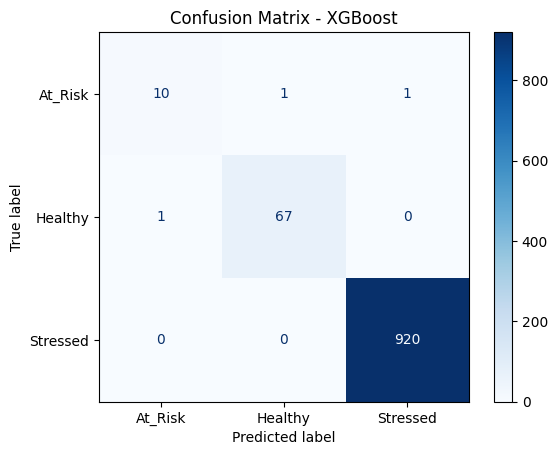

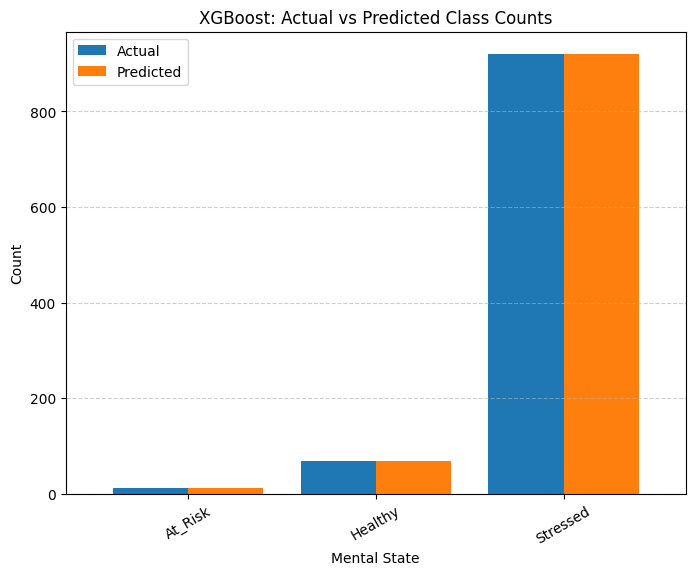

In [27]:
# 5. XGBOOST SECTION
print("\n=== 5. XGBoost Classifier ===")
# XGBoost (no SMOTE needed, handles imbalance well)
xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train_preprocessed, y_train_class)
# Predictions
y_pred_xgb = xgb_model.predict(X_test_preprocessed)
y_prob_xgb = xgb_model.predict_proba(X_test_preprocessed)
# Metrics
acc_xgb = accuracy_score(y_test_class, y_pred_xgb)
prec_xgb = precision_score(y_test_class, y_pred_xgb, average='macro')
rec_xgb = recall_score(y_test_class, y_pred_xgb, average='macro')
f1_xgb = f1_score(y_test_class, y_pred_xgb, average='macro')
auc_xgb = roc_auc_score(y_test_class, y_prob_xgb, average='macro', multi_class='ovr')
print(f"Accuracy: {acc_xgb:.4f} | Precision: {prec_xgb:.4f} | Recall: {rec_xgb:.4f} | F1: {f1_xgb:.4f} | AUC: {auc_xgb:.4f}")
# Confusion Matrix
cm_xgb = confusion_matrix(y_test_class, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=le.classes_)
disp_xgb.plot(cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.show()
# Actual vs Predicted
pred_counts_xgb = pd.Series(le.inverse_transform(y_pred_xgb)).value_counts().reindex(classes, fill_value=0)
df_bar_xgb = pd.DataFrame({'Actual': actual_counts_log, 'Predicted': pred_counts_xgb})
df_bar_xgb.plot(kind='bar', figsize=(8, 6), width=0.8)
plt.title('XGBoost: Actual vs Predicted Class Counts')
plt.ylabel('Count')
plt.xlabel('Mental State')
plt.xticks(rotation=30)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


=== Overall Model Comparison ===
                  Model  Accuracy  Macro Precision  Macro Recall  Macro F1  \
0  Linear Reg (rounded)     0.940           0.6463        0.4314    0.4743   
1          Logistic Reg     0.985           0.8155        0.9855    0.8674   
2         Decision Tree     0.999           0.9996        0.9722    0.9853   
3         Random Forest     1.000           1.0000        1.0000    1.0000   
4               XGBoost     0.997           0.9644        0.9395    0.9514   

   Macro AUC  
0     0.0000  
1     0.9978  
2     0.9840  
3     1.0000  
4     0.9999  


C:\Users\msarv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<Figure size 1200x600 with 0 Axes>

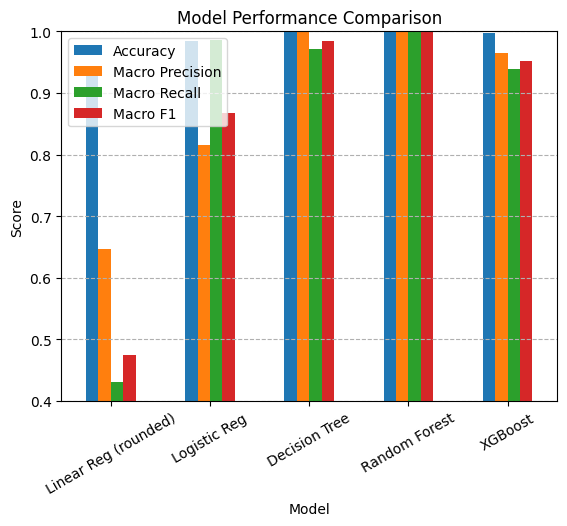

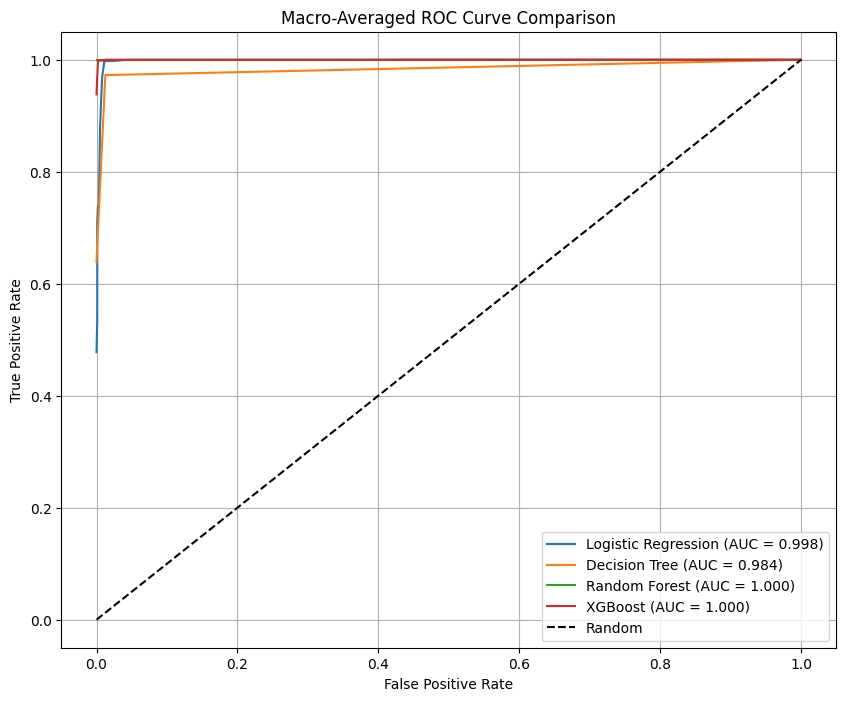

In [ ]:
# 6. OVERALL COMPARISON (Performance Summary Table)
results_summary = pd.DataFrame({
    'Model': ['Linear Reg (rounded)', 'Logistic Reg', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test_class, y_pred_class_lin), acc_log, acc_dt, acc_rf, acc_xgb],
    'Macro Precision': [precision_score(y_test_class, y_pred_class_lin, average='macro'), prec_log, prec_dt, prec_rf, prec_xgb],
    'Macro Recall': [recall_score(y_test_class, y_pred_class_lin, average='macro'), rec_log, rec_dt, rec_rf, rec_xgb],
    'Macro F1': [f1_score(y_test_class, y_pred_class_lin, average='macro'), f1_log, f1_dt, f1_rf, f1_xgb],
    'Macro AUC': [0, auc_log, auc_dt, auc_rf, auc_xgb]  # Linear Reg has no probas
}).round(4)
print("\n=== Overall Model Comparison ===")
print(results_summary)

# Bar Plot Comparison
plt.figure(figsize=(12, 6))
results_summary.set_index('Model')[
    ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.4, 1.0)   # <-- ONLY show 0.4–1.0
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--')
plt.legend()
plt.show()

# Macro-Averaged ROC Curve Comparison
plt.figure(figsize=(10, 8))
models_prob = {
    'Logistic Regression': y_prob_log,
    'Decision Tree': y_prob_dt,
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb
}
for name, y_prob in models_prob.items():
    fpr_dict, tpr_dict = {}, {}
    for i in range(len(le.classes_)):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_class == i, y_prob[:, i])

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(len(le.classes_))]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(len(le.classes_)):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])

    mean_tpr /= len(le.classes_)
    auc = roc_auc_score(y_test_class, y_prob, average='macro', multi_class='ovr')

    plt.plot(all_fpr, mean_tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Averaged ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\msarv\AppData\Local\Temp\ipykernel_26792\3335170056.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


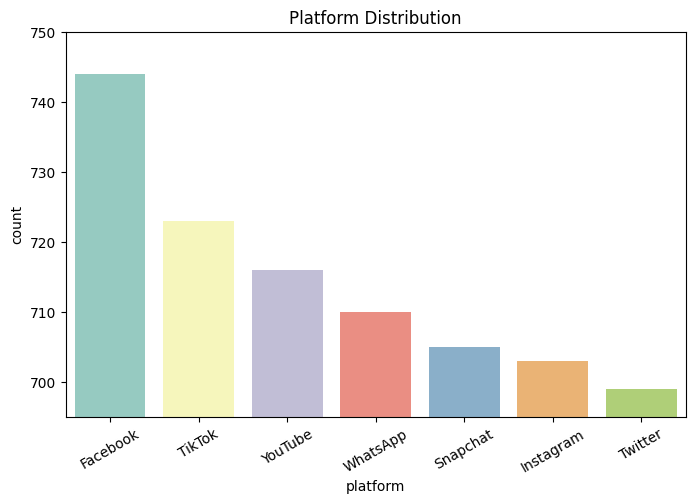

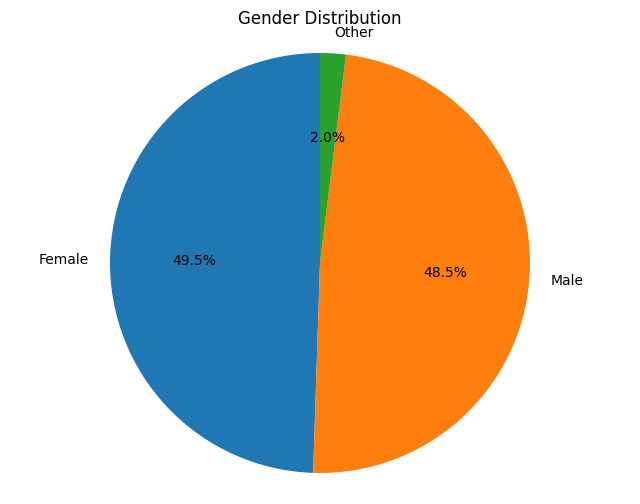

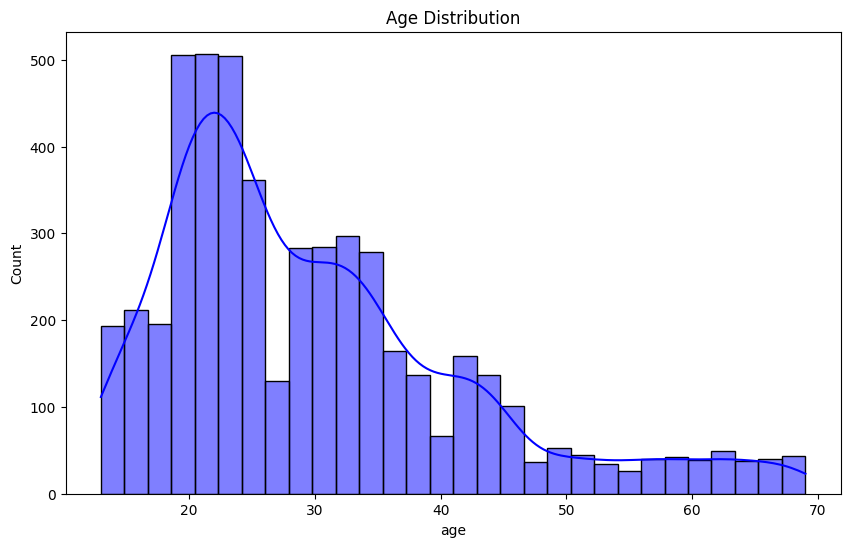

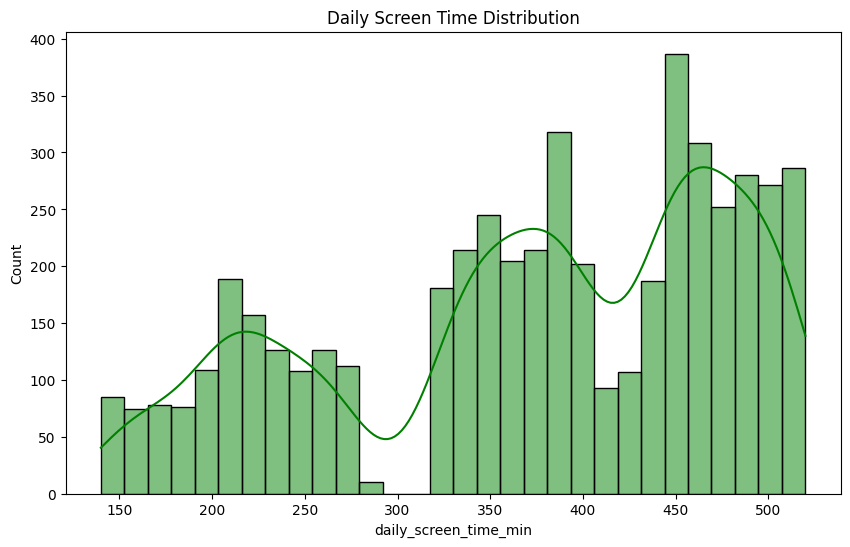

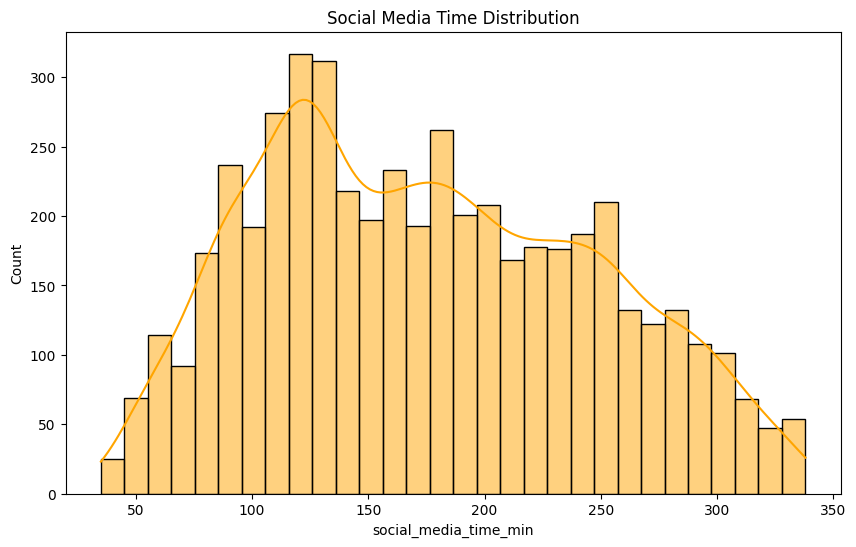

In [ ]:
# 7. ORIGINAL DATA VISUALIZATIONS EXTRA PLOTS (Platform, Gender, Age, Screen Time, etc.)
#Platform Distribution
plt.figure(figsize=(8, 5))
sns.countplot(
    x='platform',
    data=df,
    order=df['platform'].value_counts().index,
    palette='Set3'
)
plt.title('Platform Distribution')
plt.xticks(rotation=30)
plt.ylim(695, 750)  
plt.show()

#Gender Distribution - Pie Chart
plt.figure(figsize=(8, 6))
gender_counts = df['gender'].value_counts()
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Gender Distribution') 
plt.axis('equal') 
plt.show()
#Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True, color='blue')
plt.title('Age Distribution')
plt.show()
#Daily Screen Time Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['daily_screen_time_min'], bins=30, kde=True, color='green')
plt.title('Daily Screen Time Distribution')
plt.show()
#Social Media Time Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['social_media_time_min'], bins=30, kde=True, color='orange')
plt.title('Social Media Time Distribution')
plt.show()